# Blackjack Reinforcement Learning

Dieses Notebook trainiert zwei tabellarische Q-Learning-Agenten fuer `BlackjackEnv` und wertet sie danach auf derselben deterministischen Shoe-Sequenz aus.

- `Basic`: Spiel-Policy und Einsatz-Policy ohne Count.
- `Counting`: gleiche Spiel-Policy, aber die Einsatz-Policy sieht den True-Count-Bucket.

Der Agent waehlt erst den Einsatz und danach die Casino-Aktion. Der Action Space umfasst `hit`, `stand`, `double`, `split` und `surrender`; illegale Aktionen werden pro Hand maskiert.

## 1. Setup

Die Experimentlogik liegt in `agents.py`. Das Notebook bleibt dadurch lesbar und zeigt nur den Ablauf: konfigurieren, Seed pruefen, Training laden oder ausfuehren, auswerten.

Wenn du Code in `agents.py` aenderst, fuehre die Import-Zelle erneut aus. Sie laedt das Modul aktiv neu, damit Jupyter keine alten Funktionen im Kernel behaelt.

In [1]:
import os
from dataclasses import replace
from pathlib import Path

candidate_roots = [
    Path.cwd(),
    Path(r"C:\Users\lipal\IdeaProjects\ml-blackjack"),
]

for root in candidate_roots:
    if (root / "blackjack.py").exists():
        os.chdir(root)
        break
else:
    raise FileNotFoundError("blackjack.py not found. Start Jupyter from the project root.")

print(f"Working directory: {Path.cwd()}")

Working directory: C:\Users\lipal\IdeaProjects\ml-blackjack


In [2]:
import importlib
import agents as agents_module

agents_module = importlib.reload(agents_module)

from agents import (
    ExperimentConfig,
    build_test_decks,
    config_table,
    evaluate_agent_comparison,
    evaluation_comparison_table,
    evaluate_basic_strategy,
    load_training_export,
    make_env,
    plot_betting_policy_heatmaps,
    plot_evaluation_dashboard,
    plot_policy_heatmaps,
    plot_training_dashboard,
    policy_alignment_table,
    save_training_export,
    train_agent_comparison,
    training_comparison_table,
)

## 2. Parameter

Aendere die Werte in `USER_PARAMETERS`, um das Experiment zu steuern. Die Tabelle darunter zeigt dieselben Einstellungen gruppiert und mit Beschreibung.

Die Default-Regeln sind casino-nah: 6-Deck-Shoe, 75% Penetration, Dealer-Peek bei Ace/10, Blackjack zahlt 3:2, Dealer steht auf Soft 17, Double, Split, Double-after-split und Late Surrender sind aktiv. Split-Aces bekommen standardmaessig nur eine Karte, Resplit-Aces ist aus.

`RUN_AGENTS_IN_PARALLEL = True` trainiert und evaluiert Basic und Counting in getrennten Prozessen. Der Fortschritt wird dann als ruhiger Gesamtbalken angezeigt. `TRAINING_EXPORT_PATH` speichert oder laedt trainierte Q-Tabellen. Pickle-Dateien bitte nur aus diesem Projekt laden. Der Export ist versioniert; alte Exporte werden bei inkompatibler Logik automatisch verworfen und neu trainiert.

In [3]:
USER_PARAMETERS = {
    # Laufgroesse
    "base_seed": 20260526,
    "max_training_rounds": 5_000_000,
    "eval_rounds": 1_000_000,

    # Wallet und Einsaetze
    "training_bankroll": 250,
    "training_wallets": None,
    "evaluation_bankroll": 250,
    "evaluation_wallets": None,
    "bet_unit": 10,
    "max_bet_units": 10,
    "bankruptcy_penalty": -50,
    "bet_policy_override_margin": 5.0,

    # Q-Learning
    "alpha": 0.05,
    "gamma": 1.0,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.9995,
    "basic_strategy_override_margin": 0.75,

    # Casino-Regeln
    "num_decks": 6,
    "shoe_penetration": 0.75,
    "blackjack_payout": 1.5,
    "stand_on_soft_17": True,
    "dealer_peek": True,
    "allow_double": True,
    "allow_split": True,
    "allow_surrender": True,
    "double_after_split": True,
    "max_split_hands": 4,
    "hit_split_aces": False,
    "resplit_aces": False,

    # Plot-Glaettung
    "learning_curve_window": 2_000,
    "bankruptcy_rate_window": 2_000,
}

RUN_AGENTS_IN_PARALLEL = True
TRAINING_EXPORT_PATH = Path("exports") / "blackjack_training.pkl"
LOAD_TRAINING_EXPORT_IF_COMPATIBLE = True
SAVE_TRAINING_EXPORT = True

config = ExperimentConfig(**USER_PARAMETERS)
config_table(config)

,Group,Setting,Parameter,Value,Description
0,Run size,Training rounds,max_training_rounds,"5,000,000",Number of Q-learning hands per agent.
1,Run size,Evaluation rounds,eval_rounds,"1,000,000",Number of deterministic test hands per agent.
2,Run size,Base seed,base_seed,"20,260,526",Root seed for training and shared evaluation s...
3,Bankroll,Training wallet,training_bankroll,250,Money in one training wallet before a ruin reset.
4,Bankroll,Evaluation wallet,evaluation_bankroll,250,Money in one test wallet before a ruin reset.
5,Bankroll,Training wallet limit,training_wallets,unlimited,None means unlimited training wallets.
6,Bankroll,Evaluation wallet limit,evaluation_wallets,unlimited,None means unlimited evaluation wallets.
7,Betting,Minimum bet / bet unit,bet_unit,10,Smallest bet and step size for the learned bet...
8,Betting,Maximum bet units,max_bet_units,10,Maximum learned bet is bet_unit * max_bet_units.
9,Learning,Learning rate,alpha,0.05,Q-learning update step size.


## 3. Seed-Check

Der Check stellt sicher, dass gleiche Seeds gleiche Shoes erzeugen und die Shared-Test-Shoes reproduzierbar sind.

In [4]:
seed_env_a = make_env("basic", config, seed=config.base_seed, bankroll=config.training_bankroll)
seed_env_b = make_env("basic", config, seed=config.base_seed, bankroll=config.training_bankroll)
assert seed_env_a.deck == seed_env_b.deck

seed_check_config = replace(config, eval_rounds=3)
assert build_test_decks(seed_check_config) == build_test_decks(seed_check_config)

print("Seed check passed: environment shoes and shared test shoes are deterministic.")

Seed check passed: environment shoes and shared test shoes are deterministic.


## 4. Training laden oder ausfuehren

Wenn `TRAINING_EXPORT_PATH` existiert und exakt zur aktuellen Config, Export-Version und Action-Space passt, wird das Training geladen. Sonst werden beide Agenten neu trainiert und danach optional exportiert.

Der Basic-Agent lernt Spiel-Policy und Einsatz-Policy. Der Counting-Agent nutzt danach dieselbe Spiel-Policy wie Basic und lernt nur eine eigene Einsatz-Policy mit True Count. Dadurch misst der Vergleich wirklich den Nutzen des Count-Bettings und nicht zwei zufaellig unterschiedlich schlechte Spielstrategien.

Die Spielentscheidungen sind mit Basic Strategy abgesichert: eine gelernte Aktion darf Basic Strategy nur ueberschreiben, wenn ihr Q-Wert mindestens `basic_strategy_override_margin` besser ist.

In [5]:
training_results = None

if LOAD_TRAINING_EXPORT_IF_COMPATIBLE and TRAINING_EXPORT_PATH.exists():
    try:
        loaded_results, loaded_config = load_training_export(TRAINING_EXPORT_PATH)
        if loaded_config == config:
            training_results = loaded_results
            print(f"Loaded training export: {TRAINING_EXPORT_PATH}")
        else:
            print("Training export exists, but its config differs from the current USER_PARAMETERS. Training will run again.")
    except Exception as exc:
        print(f"Could not load training export ({exc}). Training will run again.")

if training_results is None:
    training_results = train_agent_comparison(
        config,
        parallel=RUN_AGENTS_IN_PARALLEL,
    )
    if SAVE_TRAINING_EXPORT:
        saved_path = save_training_export(training_results, config, TRAINING_EXPORT_PATH)
        print(f"Saved training export: {saved_path}")

basic_train = training_results["Basic"]
counting_train = training_results["Counting"]

training_comparison_table(training_results)

Could not load training export (Training export version is not supported.). Training will run again.


Training agents:   0%|          | 0/10000000 [00:00<?]

Saved training export: exports\blackjack_training.pkl


,Basic,Counting
Metric,,
Avg learning reward,-0.4396,-0.0732
Ruins (wallet bankruptcies),"7,396","1,244"
Ruin rate,0.15%,0.02%
Rounds per ruin,676.0,"4,019.3"
Avg money reward,-0.3657,-0.0608
Wallets used,"7,397 / unlimited","1,245 / unlimited"
Avg chosen bet,13.70,14.96
Current wallet budget,"1,100.00","4,335.00"
Final epsilon,0.0500,0.0500


### Training-Export

Der Export ist eine Pickle-Datei mit vier Teilen: `version`, `config`, `action_names` und `training_results`. `training_results` enthaelt die Q-Tabelle fuer Spielentscheidungen, die Q-Tabelle fuer Einsatzentscheidungen und die Trainingsmetriken. Beim Laden wird geprueft, ob Version, Action-Space und Config passen. Wenn nicht, wird neu trainiert. Lade Pickle-Dateien nur aus diesem Projekt, weil Pickle Python-Code ausfuehren kann.

## 5. Policy-Check gegen Basic Strategy

Diese Tabelle prueft, wie oft die Greedy-Spielentscheidung der Agenten mit Basic Strategy uebereinstimmt. Wenn die Werte hier schlecht sind, ist die Evaluation nicht als realistisches Blackjack-Spiel zu interpretieren.

In [6]:
policy_alignment_table(training_results)

,Basic,Counting
Metric,,
Basic-strategy agreement,98.9%,98.9%
Hard-hand agreement,98.8%,98.8%
Soft-hand agreement,97.5%,97.5%
Pair-hand agreement,100.0%,100.0%
Different first-decision cells,4,4


## 6. Training-Dashboard

Die Plots zeigen Lernreward, gewaehlte Einsaetze, Bankruptcy-Rate, Wallet-Verlauf, Exploration und die Einsatzverteilung. Durch Downsampling und geglaettete Trends bleiben die Kurven auch bei 5 Mio. Trainingsrunden lesbar.

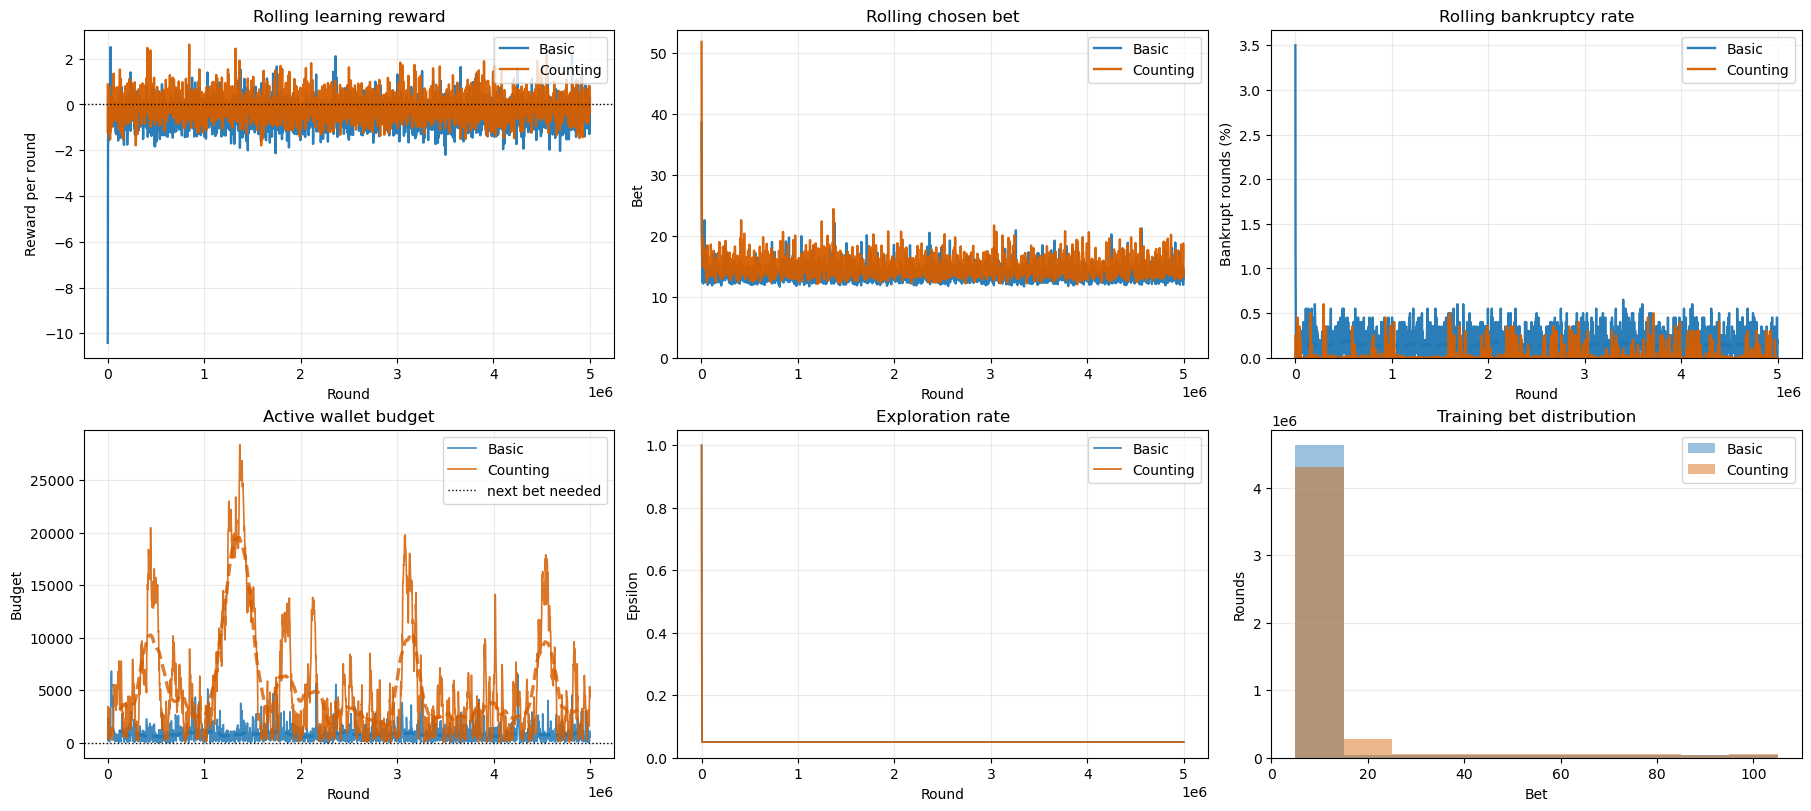

In [7]:
plot_training_dashboard(training_results, config)

## 7. Gelernte Einsatz-Policy

Die Heatmaps zeigen den gierigen Einsatz fuer verschiedene Wallet-Buckets. Beim Counting-Agenten ist zusaetzlich der True Count auf der X-Achse sichtbar.

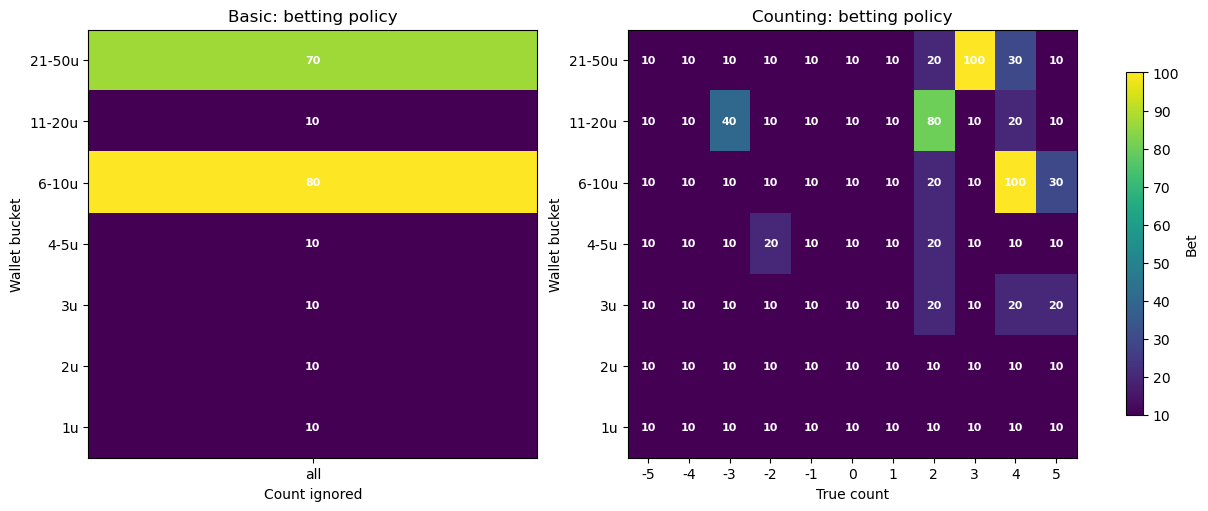

In [8]:
plot_betting_policy_heatmaps(
    {
        "Basic": ("basic", basic_train.bet_q_table),
        "Counting": ("extended", counting_train.bet_q_table),
    },
    config,
)

## 8. Gelernte Spiel-Policy

Die Heatmaps zeigen die Greedy-Policy fuer typische erste Entscheidungen. `H` = Hit, `S` = Stand, `D` = Double, `P` = Split, `R` = Surrender. Die dritte Zeile der Policy-Grafik zeigt Paarhaende separat.

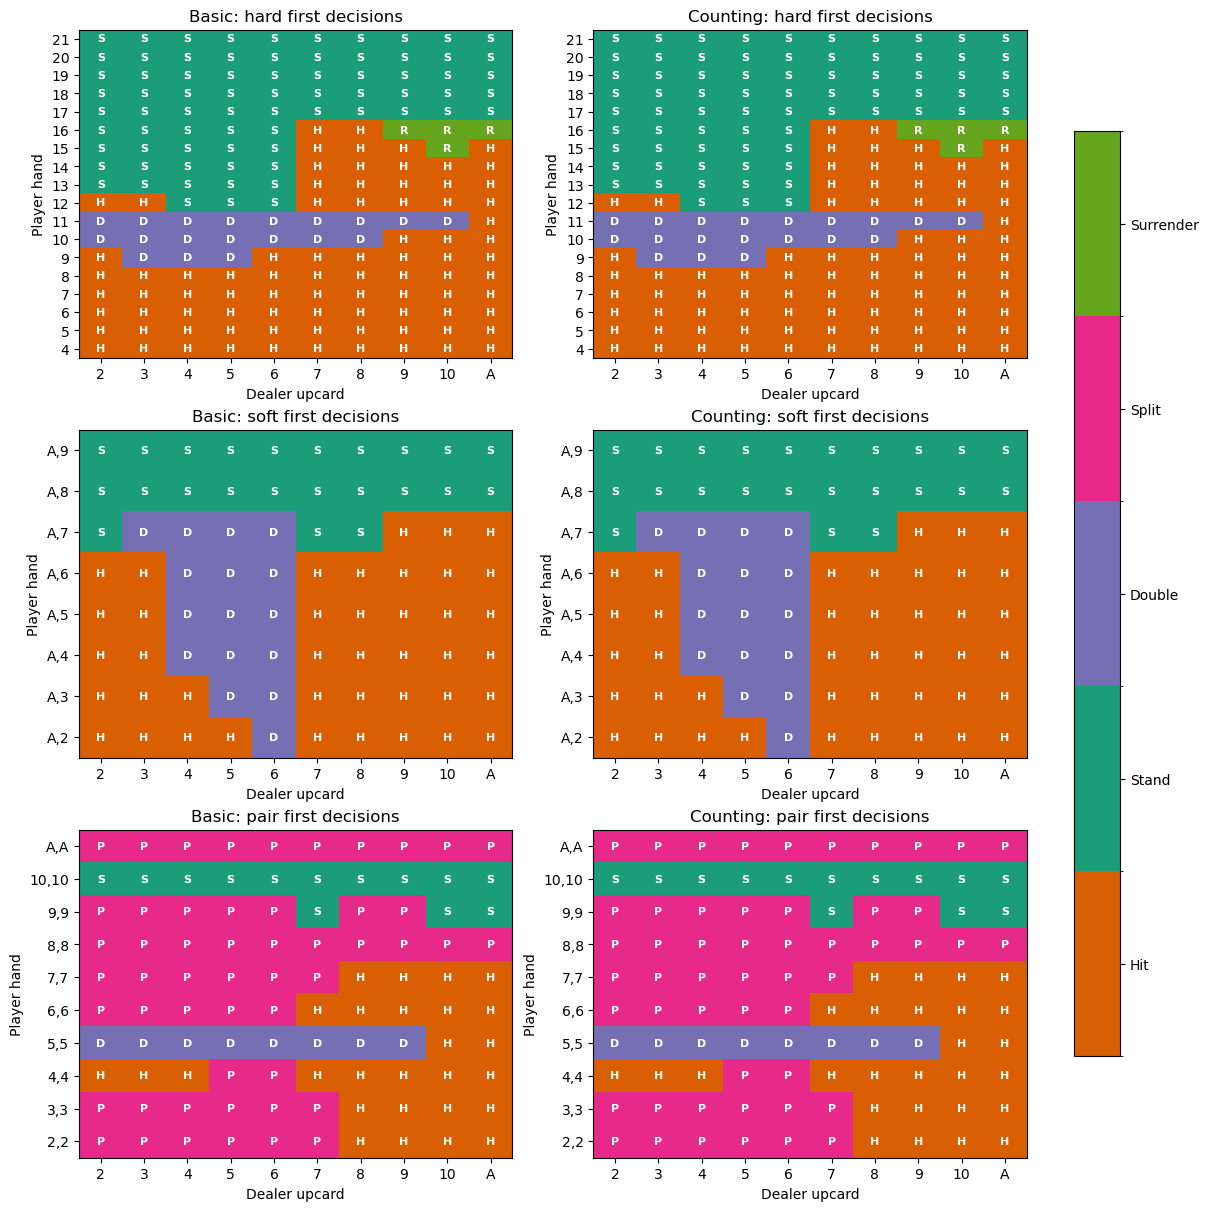

In [9]:
plot_policy_heatmaps(
    {
        "Basic": (basic_train.play_state_mode, basic_train.q_table),
        "Counting": (counting_train.play_state_mode, counting_train.q_table),
    },
    true_count=0,
)

## 9. Evaluation auf gemeinsamen Test-Shoes

Jetzt zaehlt echtes Testgeld. Zuerst wird eine feste Basic-Strategy-Benchmark mit Minimum-Bet ausgewertet. Danach laufen Basic und Counting auf derselben deterministischen Test-Shoe-Sequenz. Wenn ein Shoe weit genug ausgespielt ist, wird der naechste Shoe geladen. Wenn ein Wallet nicht mehr fuer den Mindesteinsatz reicht, wird ein neues Wallet geoeffnet.

In [10]:
shared_test_shoes = build_test_decks(config)

print(f"Shared test shoes: {len(shared_test_shoes):,} rounds, seed {config.test_deck_seed}")

basic_strategy_eval = evaluate_basic_strategy(
    shared_test_shoes,
    config,
    show_progress=True,
)
agent_evaluation_results = evaluate_agent_comparison(
    training_results,
    shared_test_shoes,
    config,
    parallel=RUN_AGENTS_IN_PARALLEL,
)

evaluation_results = {
    "Basic Strategy": basic_strategy_eval,
    **agent_evaluation_results,
}

basic_eval = evaluation_results["Basic"]
counting_eval = evaluation_results["Counting"]

evaluation_comparison_table(evaluation_results)

Shared test shoes: 1,000,000 rounds, seed 20260626


Evaluating Basic Strategy:   0%|          | 0/1000000 [00:00<?]

Evaluating agents:   0%|          | 0/2000000 [00:00<?]

,Basic Strategy,Basic,Counting
Metric,,,
Penalty-adjusted score,"-57,540.00","-58,555.00","-126,605.00"
Net money profit,"-47,740.00","-48,505.00","-104,855.00"
Ruins (wallet bankruptcies),196,201,435
Ruin rate,0.02%,0.02%,0.04%
Rounds per ruin,"5,102.0","4,975.1","2,298.9"
Total cash remaining,"1,510.00","1,995.00","4,145.00"
Total capital injected,"49,250.00","50,500.00","109,000.00"
Wallets used,197 / unlimited,202 / unlimited,436 / unlimited
Avg penalty-adjusted score,-0.0575,-0.0586,-0.1266


## 10. Evaluation-Dashboard

Die Auswertung trennt Verlauf und Endergebnis: Net Profit, Rolling Reward, Einsatzverlauf, aktiver Wallet, Einsatzverteilung und finaler Score-Vergleich. Die Farben bleiben ueber alle Plots hinweg pro Agent gleich.

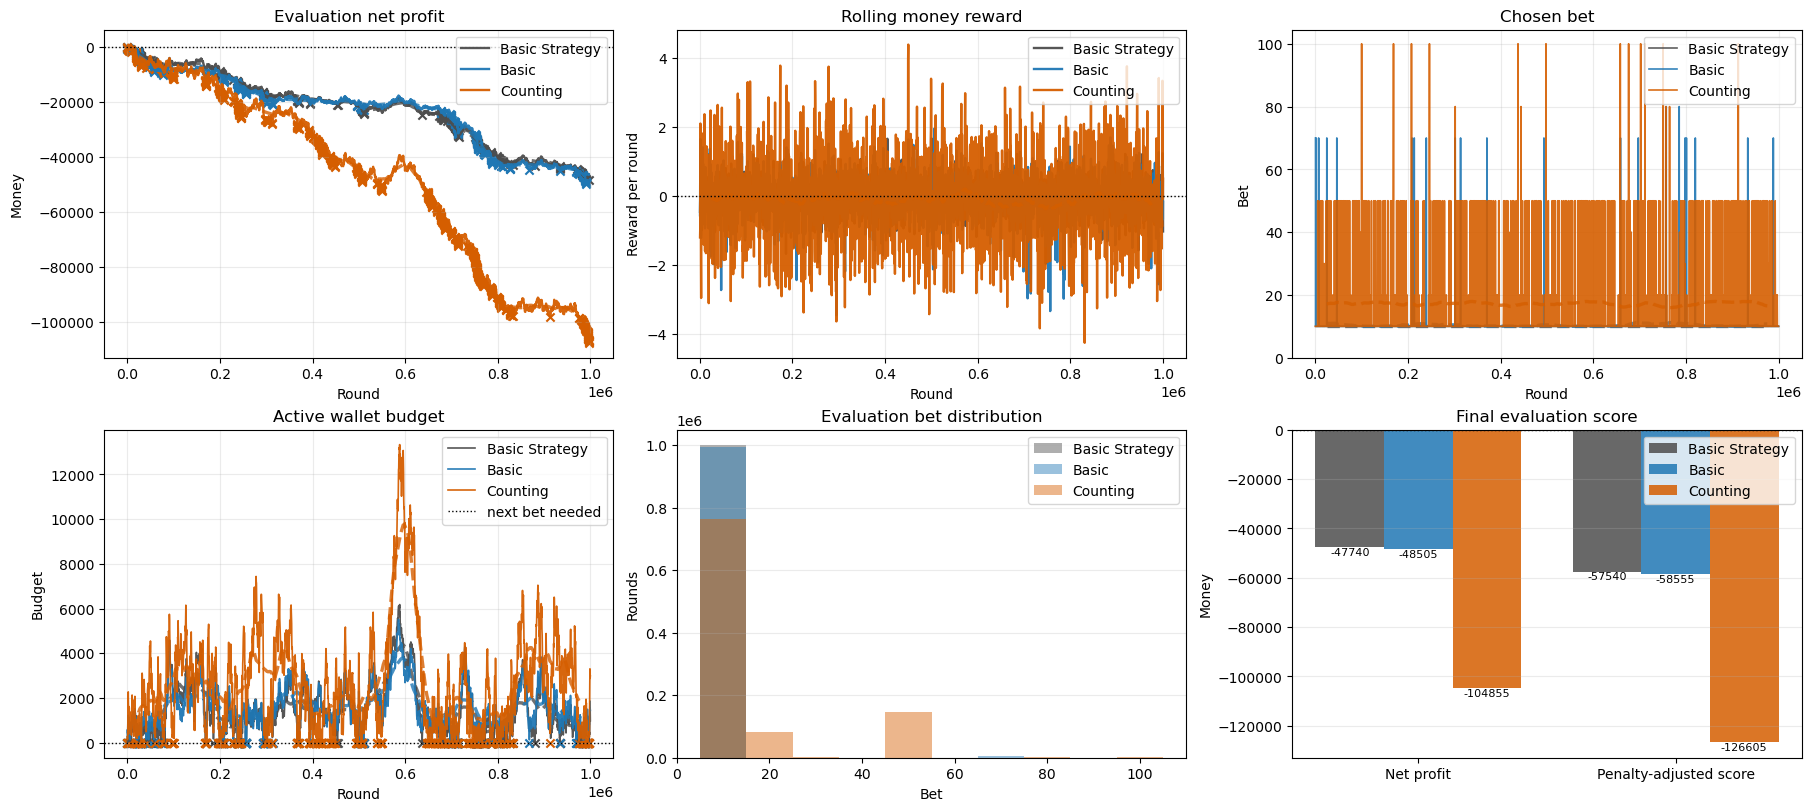

In [11]:
plot_evaluation_dashboard(evaluation_results, config)